# Lifetime PD with parametric survival models

A walk through the model: the data, the encoding it rests on, how the distribution
was chosen, and what the fitted model says about lifetime default risk.

The macroeconomic series are real. The loan book is simulated, because no loan-level
survival panel is public without registration — see the README for what that buys
and what it costs.


In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

from creditsurv.cli import default_covariates
from creditsurv.config import default_formula
from creditsurv.data.fred import load_macro_panel
from creditsurv.data.store import load_panel

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)

macro = load_macro_panel()
panel = load_panel()
covariates, formula = default_covariates(), default_formula()
print(
    f"{len(panel):,} loan-months, {panel.loan_id.nunique():,} loans, "
    f"{int(panel.event.sum()):,} defaults"
)
macro.tail(3).round(2)

429,945 loan-months, 10,000 loans, 656 defaults


,unemployment_rate,hpi,mortgage_rate_30y,nfci
period,,,,
2026-04,4.3,333.11,6.33,-0.48
2026-05,4.3,335.43,6.44,-0.51
2026-06,4.2,336.66,6.49,-0.51


## The loan book responds to real macroeconomic history

Nothing imposes a crisis on the simulation. Vintages originated into 2006 meet the
housing collapse through `cltv_drift` and `unemp_gap`, both built from actual FRED
series, and the vintage default curve comes out looking like the real one.


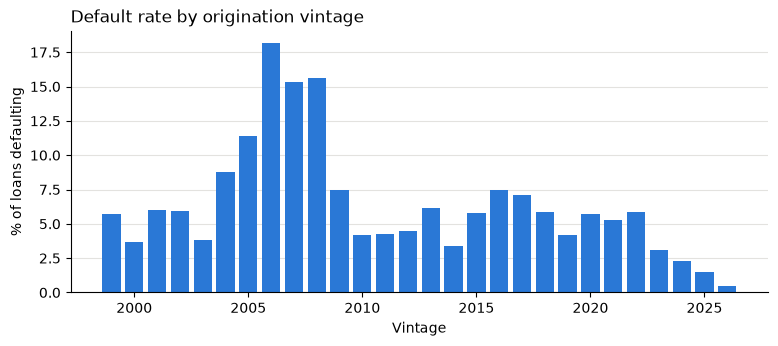

In [2]:
first = panel.groupby("loan_id").first()
outcome = panel.groupby("loan_id").event.max()
by_vintage = (
    first.assign(year=first.orig_period.dt.year, defaulted=outcome)
    .groupby("year")
    .defaulted.agg(["mean", "size"])
)
by_vintage = by_vintage[by_vintage["size"] > 100]

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(by_vintage.index, by_vintage["mean"] * 100, color="#2a78d6")
ax.set_title("Default rate by origination vintage", loc="left")
ax.set_ylabel("% of loans defaulting")
ax.set_xlabel("Vintage")
ax.grid(axis="y", color="#e3e2df")
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.show()

## The encoding

Each loan-month becomes one episode. A surviving month contributes
`log[S(a+1)/S(a)]`; the defaulting month contributes `log[1 − S(a+1)/S(a)]`, with the
bounds bracketing the month rather than pinning a day to it.

Note `exact_observation` is `False` on every row, including the default. lifelines
uses that flag to mean the event time is known *exactly*; monthly reporting never is.


In [3]:
from creditsurv.data.panel import to_interval_censored

encoded = to_interval_censored(panel)
one = encoded[encoded.loan_id == encoded[encoded.event].loan_id.iloc[0]]
one[
    [
        "loan_id",
        "period",
        "age",
        "age_start",
        "lower_bound",
        "upper_bound",
        "exact_observation",
        "event",
    ]
].tail(6)

,loan_id,period,age,age_start,lower_bound,upper_bound,exact_observation,event
127,2,2017-10,7,7.0,8.0,inf,False,False
128,2,2017-11,8,8.0,9.0,inf,False,False
129,2,2017-12,9,9.0,10.0,inf,False,False
130,2,2018-01,10,10.0,11.0,inf,False,False
131,2,2018-02,11,11.0,12.0,inf,False,False
132,2,2018-03,12,12.0,12.0,13.0,False,True


## Choosing the distribution

The marginal comparison is covariate-free and cheap: it cannot decide the final
model, but it catches a badly wrong family before any regression is attempted.


In [4]:
from creditsurv.models.selection import marginal_comparison

marginal_comparison(panel).round(2)

,distribution,log_likelihood,aic,n_parameters,delta_aic
0,loglogistic,-4889.35,9782.69,2,0.00
1,lognormal,-4889.40,9782.79,2,0.10
2,weibull,-4890.03,9784.07,2,1.37
3,exponential,-4910.33,9822.65,1,39.96


## Fitting

A Weibull AFT over the episode panel, with interval bounds and left truncation, so
the model is fully parametric *and* carries time-varying covariates.

`exp(coef)` here is a **time ratio**, not a hazard ratio: positive coefficients
lengthen expected survival and therefore lower risk.


In [5]:
from creditsurv.models.aft import coefficient_table, fit_aft

fitted = fit_aft(encoded, covariates, formula)
print(
    f"{fitted.n_episodes:,} episodes, {fitted.n_events:,} defaults, "
    f"AIC {fitted.aic:,.1f}, {fitted.elapsed_seconds:.0f}s"
)
coefficient_table(fitted).round(4).head(12)

429,945 episodes, 656 defaults, AIC 9,234.5, 64s


coef  se(coef)  time_ratio  coef lower 95%  \
param   covariate                                                                                          
lambda_ Intercept                                           8.4136    0.9271   4507.7462          6.5964   
        fico_s                                              0.3791    0.0535      1.4609          0.2741   
        orig_ltv                                           -0.0130    0.0034      0.9871         -0.0198   
        dti                                                -0.0096    0.0041      0.9904         -0.0176   
        log_orig_upb                                       -0.0778    0.0715      0.9251         -0.2179   
        orig_spread                                        -0.0701    0.1725      0.9323         -0.4082   
        cltv_drift                                         -0.0202    0.0032      0.9800         -0.0264   
        unemp_gap                                          -0.0890    0.0154      0.9149         -0.1192   
        refi_incentive                                      0.0097    0.0312      1.0097         -0.0515   
        nfci_lagged                                        -0.2126    0.0382      0.8085         -0.2874   
        C(purpose, Treatment('purchase'))[T.refinance_r...  0.0340    0.0728      1.0346         -0.1086   
        C(purpose, Treatment('purchase'))[T.refinance_c... -0.3520    0.0741      0.7033         -0.4972   

                                                            coef upper 95%       p  
param   covariate                                                                   
lambda_ Intercept                                                  10.2307  0.0000  
        fico_s                                                      0.4840  0.0000  
        orig_ltv                                                   -0.0063  0.0002  
        dti                                                        -0.0016  0.0182  
        log_orig_upb                                                0.0622  0.2761  
        orig_spread                                                 0.2680  0.6846  
        cltv_drift                                                 -0.0140  0.0000  
        unemp_gap                                                  -0.0587  0.0000  
        refi_incentive                                              0.0709  0.7568  
        nfci_lagged                                                -0.1378  0.0000  
        C(purpose, Treatment('purchase'))[T.refinance_r...          0.1767  0.6403  
        C(purpose, Treatment('purchase'))[T.refinance_c...         -0.2067  0.0000

## Is the shape supported by the data?

Kaplan-Meier assumes nothing about the distribution, so a fitted curve leaving its
confidence band is being contradicted rather than merely smoothed.

The curve below chains the monthly hazard along each loan's *realised* covariate
path. Predicting instead from origination covariates — the obvious approach — left
only half the horizon inside the band, because `cltv_drift` and `unemp_gap` are zero
at origination by construction.


60 of 60 points inside the band


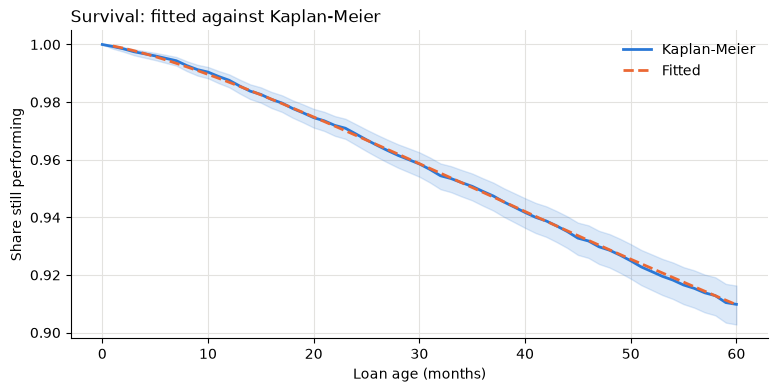

In [6]:
from creditsurv.models.nonparametric import (
    kaplan_meier,
    km_band_contains,
    predicted_survival_curve,
)

curve = kaplan_meier(panel)
predicted = predicted_survival_curve(fitted, encoded, covariates)
band = km_band_contains(curve, predicted)
print(f"{int(band.inside.sum())} of {len(band)} points inside the band")

fig, ax = plt.subplots(figsize=(9, 4))
ci = curve.confidence_interval_survival_function_
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="#2a78d6", alpha=0.16)
ax.plot(
    curve.survival_function_.index,
    curve.survival_function_.iloc[:, 0],
    color="#2a78d6",
    lw=2,
    label="Kaplan-Meier",
)
ax.plot(predicted.index, predicted, color="#eb6834", lw=2, ls="--", label="Fitted")
ax.set_title("Survival: fitted against Kaplan-Meier", loc="left")
ax.set_xlabel("Loan age (months)")
ax.set_ylabel("Share still performing")
ax.legend(frameon=False)
ax.grid(color="#e3e2df")
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.show()

## Lifetime PD and its term structure

Two portfolios can share a lifetime PD and differ completely in *when* the losses
arrive. The term structure is what says which.


12-month PD  0.50%
lifetime PD  3.93%


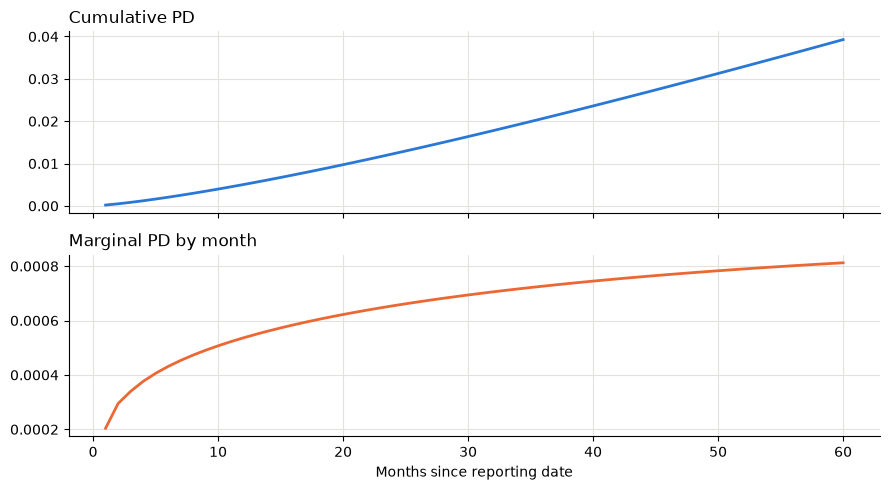

In [7]:
from creditsurv.data.panel import at_origination
from creditsurv.models.lifetime_pd import (
    conditional_pd,
    extend_macro,
    pd_term_structure,
    project_panel,
    survival_along_path,
)

book = at_origination(panel).head(800).copy()
book["age"] = 0
book["period"] = macro.index.max() + 1

forward = project_panel(book, extend_macro(macro, 62), horizon_months=60)
survival = survival_along_path(fitted, forward, covariates)
structure = pd_term_structure(survival)

print(f"12-month PD  {conditional_pd(survival, horizon_months=12).mean():.2%}")
print(f"lifetime PD  {conditional_pd(survival).mean():.2%}")

fig, (a, b) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
a.plot(structure.index, structure.cumulative_pd, color="#2a78d6", lw=2)
a.set_title("Cumulative PD", loc="left")
b.plot(structure.index, structure.marginal_pd, color="#eb6834", lw=2)
b.set_title("Marginal PD by month", loc="left")
b.set_xlabel("Months since reporting date")
for ax in (a, b):
    ax.grid(color="#e3e2df")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()

## Macroeconomic scenarios

Because the covariates vary over time, a scenario is applied by projecting the
covariate paths and chaining conditional survival — not by re-scoring frozen
covariates, which produces a model that returns the same answer under every scenario
and looks stable when it is simply not being asked the question.


       baseline   adverse
count  800.0000  800.0000
mean     0.0207    0.0564
std      0.0247    0.0652
min      0.0017    0.0043
25%      0.0081    0.0211
50%      0.0139    0.0363
75%      0.0250    0.0679
max      0.4169    0.8463

adverse / baseline: 2.73x


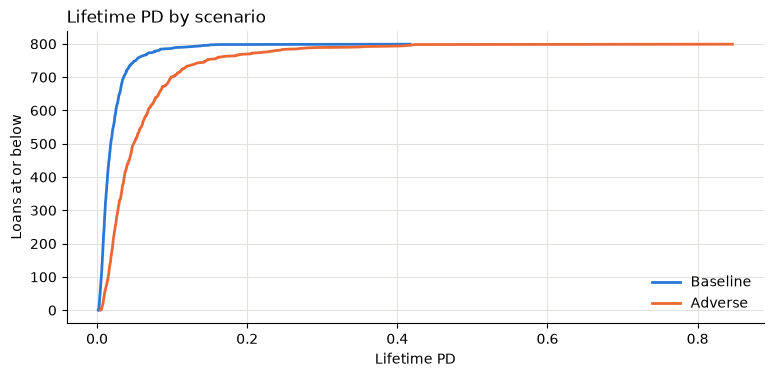

In [8]:
from creditsurv.models.lifetime_pd import scenario_lifetime_pd

scenarios = scenario_lifetime_pd(fitted, book, macro, covariates, horizon_months=36)
print(scenarios.describe().round(4))
print(f"\nadverse / baseline: {scenarios.adverse.mean() / scenarios.baseline.mean():.2f}x")

fig, ax = plt.subplots(figsize=(9, 3.8))
for colour, name in zip(("#2a78d6", "#eb6834"), scenarios.columns, strict=True):
    values = scenarios[name].sort_values()
    ax.plot(values, range(len(values)), color=colour, lw=2, label=name.capitalize())
ax.set_title("Lifetime PD by scenario", loc="left")
ax.set_xlabel("Lifetime PD")
ax.set_ylabel("Loans at or below")
ax.legend(frameon=False)
ax.grid(color="#e3e2df")
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.show()

## Where to go next

- [`reports/methodology.md`](../reports/methodology.md) — variable and model selection, fit quality
- [`reports/calibration.md`](../reports/calibration.md) — what the regressors are worth
- [`reports/backtesting.md`](../reports/backtesting.md) — out-of-time performance
- [`docs/data_dictionary.md`](../docs/data_dictionary.md) — the record layout, layer by layer
